Q3.

Team Members- Tamanna and Aabishkar

Project Title - Steady state heat equation in 2D.

Project Description -
We have to solve the steady state heat equation in 2D with the Dirichlet (i.e. temperature) boundary conditions on all sides. We apply the second order finite difference method to both spatial derivatives.
i.e-

0 = kappa*(u_xx + u_yy) + F(x, y)

for x in [0, Lx], y in [0, Ly]

with boundary conditions:

u(x, 0) = u(x, Ly) = u(0, y) = u(Lx, y) = 0

Manufactured solution:

u(x,y) = cos(2*pi*(x+y))

Deliverables-
We use an manufactured solution to confirm convergence. Explore the pros/cons of LUP versus CG.  Consider applying GPU acceleration to the matrix-vector multiply inside of CG.



Heat Equation Link -https://en.wikipedia.org/wiki/Heat_equation#Steady-state_heat_equation

Contribution-


Tamanna: Setting up the problem, basic and CG method implementation, write-up.

Aabishkar- CG GPU implementation, LUP implementation, Presentation Deck, Write-up

In [ ]:
# Installation cell
%%capture
%%shell
if ! command -v julia 3>&1 > /dev/null
then
    wget -q 'https://julialang-s3.julialang.org/bin/linux/x64/1.8/julia-1.8.2-linux-x86_64.tar.gz' \
        -O /tmp/julia.tar.gz
    tar -x -f /tmp/julia.tar.gz -C /usr/local --strip-components 1
    rm /tmp/julia.tar.gz
fi
julia -e 'using Pkg; pkg"add IJulia; precompile"'


echo 'Done'



if gpu execution run this-

In [ ]:
# Installation cell
%%capture
%%shell
if ! command -v julia 3>&1 > /dev/null
then
    wget -q 'https://julialang-s3.julialang.org/bin/linux/x64/1.7/julia-1.7.2-linux-x86_64.tar.gz' \
        -O /tmp/julia.tar.gz
    tar -x -f /tmp/julia.tar.gz -C /usr/local --strip-components 1
    rm /tmp/julia.tar.gz
fi
julia -e 'using Pkg; pkg"add IJulia; precompile;"'
echo 'Done'

In [ ]:
VERSION

v"1.8.2"

manufactured solution

In [ ]:
# install Plotting package (this will also take some time).
using Pkg
Pkg.add(["LinearAlgebra", "IterativeSolvers", "SparseArrays", "CUDA", "BenchmarkTools"], io=devnull)
using LinearAlgebra, IterativeSolvers, SparseArrays, CUDA, BenchmarkTools

# using Pkg
# Pkg.add("Plots",io=devnull)
# using Plots, SparseArrays
# """
# using Pkg
# Pkg.add(["BenchmarkTools","CUDA"],io=devnull)
# using BenchmarkTools,CUDA
# import Pkg; Pkg.add("IterativeSolvers")"""

In [ ]:
using Pkg
Pkg.add(["Plots"], io=devnull)
using Plots


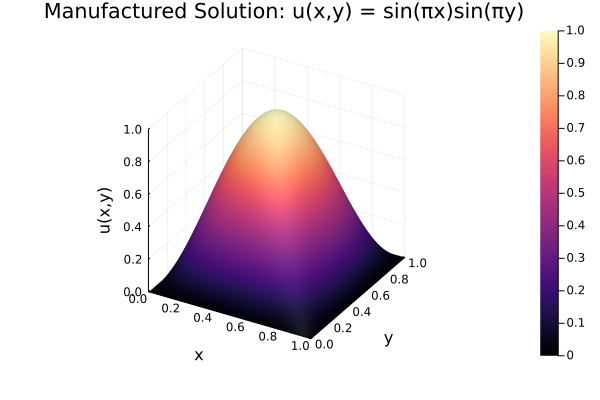

In [ ]:

# Define the domain
Lx = 1.0
Ly = 1.0
Nx = 101 # Number of points in the x direction
Ny = 101 # Number of points in the y direction

# Generate the x and y coordinates
x = LinRange(0, Lx, Nx)
y = LinRange(0, Ly, Ny)

# Create a grid using broadcasting
X, Y = [xi for yi in y, xi in x], [yi for yi in y, xi in x]

# Manufactured solution function with sine function that is zero at boundaries
u(x, y) = sin(π * x) * sin(π * y)

# Evaluate the solution over the grid
U = u.(X, Y)

# Plot the solution in 3D
p = surface(x, y, U, color=:magma, xlabel="x", ylabel="y", zlabel="u(x,y)", title="  Manufactured Solution: u(x,y) = sin(πx)sin(πy)")

# To display the plot in your environment
display(p)

In [ ]:
# Parameters for the 2D problem
kappa = 2.0  # Thermal diffusivity
Lx = 1.0     # Length of the domain in the x-direction
Ly = 1.0     # Length of the domain in the y-direction
Nx = 101 #Int(Lx / 0.1) + 1  # Number of spatial nodes in the x-direction
Ny = 101 #Int(Ly / 0.1) + 1  # Number of spatial nodes in the y-direction
dx = Lx / (Nx - 1)      # Spatial step size in the x-direction
dy = Ly / (Ny - 1)      # Spatial step size in the y-direction

# Create grids
x_space = range(0, Lx, length=Nx)
y_space = range(0, Ly, length=Ny)



0.0:0.01:1.0

In [ ]:
"""
    tridiagm(M)

Create a tridiagonal matrix representing the second-order derivative using finite differences
"""
function tridiagm(M)

  # Create A in dense format
  A = zeros(M, M)
  for i = 1:M
      A[i, i] = -2 #*kappa/dx^2
  end
  for i = 1:M-1
      A[i+1, i] = 1 #*kappa/dx^2
      A[i, i+1] = 1 #*kappa/dx^2
  end

  return A
end


"""
    Dx(M, kappa, dx)

Create the matrix for the x-derivative term
"""
function Dx(M, kappa, dx)
    A = tridiagm(M)
    D = (kappa / dx^2) * A
    return D
end

"""
    Dy(M, kappa, dy)

Create the matrix for the y-derivative term
"""
function Dy(M, kappa, dy)
    A = tridiagm(M)
    D = (kappa / dy^2) * A
    return D
end
# The corrected dimensions for interior points
Nx_int = Nx - 2  # Interior points in x
Ny_int = Ny - 2  # Interior points in y

# Construct the matrices Dx and Dy for interior points only
Dx_matrix = Dx(Nx_int, kappa, dx)
Dy_matrix = Dy(Ny_int, kappa, dy)

# Compute the Kronecker product of Dx and Dy to construct the matrix A
A = -kron(Dx_matrix, SparseArrays.spdiagm(0 => ones(Ny_int))) - kron(SparseArrays.spdiagm(0 => ones(Nx_int)), Dy_matrix)


# Define the source term for the manufactured solution
F(x, y) = ( 2*pi^2 * sin(pi*x)*sin(pi*y)) * kappa



F (generic function with 1 method)

In [ ]:


# Create the source term vector
b = reshape([F(xi, yi) for yi in y_space[2:end-1], xi in x_space[2:end-1]], (Nx_int) *(Ny_int))

# Verify the dimensions
size_A = size(A)
size_b = length(b)

# This should show the sizes are compatible
println("Size of A: $size_A, Size of b: $size_b")

#collect(A)

Size of A: (9801, 9801), Size of b: 9801


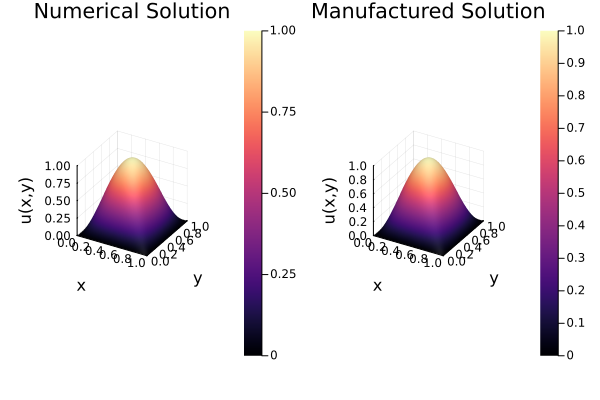

In [ ]:

# Solve the system AU = b
U = A\ b

# Create a new matrix with zeros that is larger by one row and column on each side
U_full = zeros(Ny, Nx)

# Copy the interior solution into the center of the full matrix
U_full[2:end-1, 2:end-1] =reshape(U, Ny_int, Nx_int)

# Manufactured solution function
u_manufactured(x, y) = sin(π * x) * sin(π * y)

# Evaluate the manufactured solution over the grid
U_manufactured = [u_manufactured(xi, yi) for yi in y_space, xi in x_space]

# Plot the numerical solution
p_numerical = surface(x_space, y_space, U_full, color=:magma, xlabel="x", ylabel="y", zlabel="u(x,y)", title="Numerical Solution")

# Plot the manufactured solution for comparison
p_manufactured = surface(x_space, y_space, U_manufactured, color=:magma, xlabel="x", ylabel="y", zlabel="u(x,y)", title="Manufactured Solution")

# Display both plots for comparison
plot(p_numerical, p_manufactured, layout=(1, 2))

In [ ]:
isposdef(A)

true

CG implementation - CPU

Time taken for CG method: 0.898147841 seconds


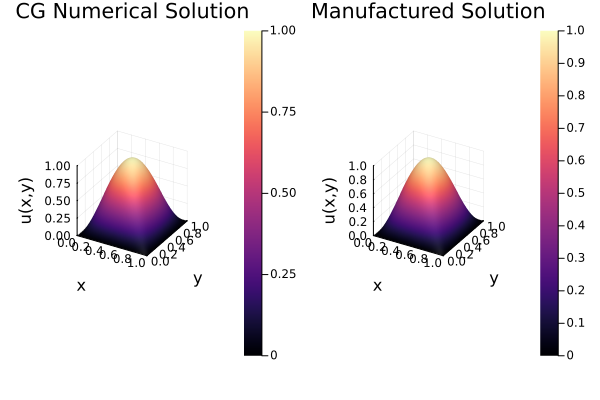

In [ ]:
# Time the execution of the CG method
cg_time = @elapsed U_cg = cg(A, b)

# Output the time taken
println("Time taken for CG method: $cg_time seconds")

# Reshape U_shifted into a 2D array for the interior solution
U_cg_matrix = reshape(U_cg, Ny_int, Nx_int)

# Initialize the full solution matrix including boundaries for CG solution
U_cg_full = zeros(Ny, Nx)

# Copy the interior CG solution into the center of the full matrix
U_cg_full[2:end-1, 2:end-1] = U_cg_matrix

# Evaluate the manufactured solution over the entire grid (including boundaries)
U_manufactured = [u_manufactured(xi, yi) for yi in y_space, xi in x_space]

# Reshape for consistency with Plots.jl expected dimensions
U_manufactured_matrix = reshape(U_manufactured, Ny, Nx)

# Plot the CG solution
p_cg = surface(x_space, y_space, U_cg_full, color=:magma, xlabel="x", ylabel="y", zlabel="u(x,y)", title="CG Numerical Solution")

# Plot the manufactured solution for comparison
p_manufactured = surface(x_space, y_space, U_manufactured_matrix, color=:magma, xlabel="x", ylabel="y", zlabel="u(x,y)", title="Manufactured Solution")

# Display both plots for comparison
plot(p_cg, p_manufactured, layout=(1, 2))

Time taken for LUP method: 0.051932436 seconds


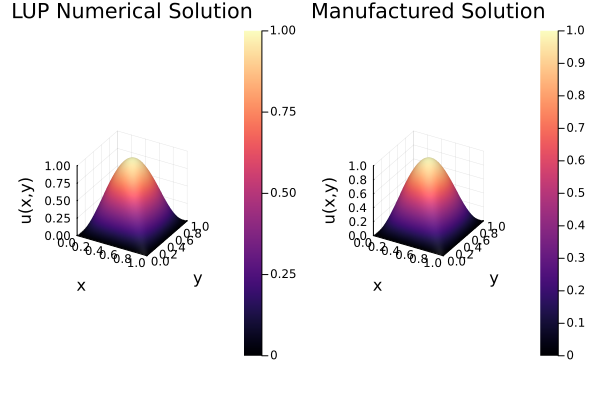

In [ ]:

"""
    solve_LUP_LinearAlgebra(A,b)
Perform LU factorization and forward-backward substitution on matrix A and solve Ax = b
"""
function solve_LUP_LinearAlgebra(A, b)
    #compute LUP factorization using lu() from LinearAlgebra
    F = lu(A; check = true) #throw error when decomposition fails
    x = F\b

    return x
end


# Time the execution of the LUP method
lup_time = @elapsed Lup_shifted = solve_LUP_LinearAlgebra(A, b)

# Output the time taken
println("Time taken for LUP method: $lup_time seconds")

# Reshape Lup_shifted into a 2D array for the interior solution
U_lup_matrix = reshape(Lup_shifted, Ny_int, Nx_int)

# Initialize the full solution matrix including boundaries for LUP solution
U_lup_full = zeros(Ny, Nx)

# Copy the interior LUP solution into the center of the full matrix
U_lup_full[2:end-1, 2:end-1] = U_lup_matrix

# Plot the LUP solution
p_lup = surface(x_space, y_space, U_lup_full, color=:magma, xlabel="x", ylabel="y", zlabel="u(x,y)", title="LUP Numerical Solution")

# Plot the manufactured solution for comparison
p_manufactured = surface(x_space, y_space, U_manufactured_matrix, color=:magma, xlabel="x", ylabel="y", zlabel="u(x,y)", title="Manufactured Solution")

# Display both plots for comparison
plot(p_lup, p_manufactured, layout=(1, 2))

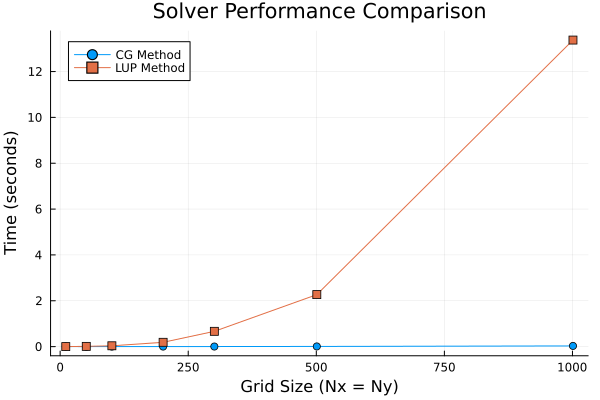

In [ ]:
# Grid sizes to test
grid_sizes = [11, 51,101,201,301,501,1001]

# Initialize arrays to store computation times
cg_times = []
lup_times = []

# Define kappa and domain lengths Lx, Ly (assuming these are constants in your problem)
kappa = 2.0
Lx = 1.0
Ly = 1.0

for N in grid_sizes
    Nx = Ny = N
    Nx_int = Nx - 2  # Interior points in x
    Ny_int = Ny - 2  # Interior points in y
    dx = Lx / (Nx - 1)
    dy = Ly / (Ny - 1)

    x_space = range(0, Lx, length=Nx)
    y_space = range(0, Ly, length=Ny)

    # Construct the matrices Dx and Dy for interior points only
    Dx_matrix = Dx(Nx_int, kappa, dx)
    Dy_matrix = Dy(Ny_int, kappa, dy)

    # Compute the Kronecker product of Dx and Dy to construct the matrix A
    A = -kron(Dx_matrix, SparseArrays.spdiagm(0 => ones(Ny_int))) - kron(SparseArrays.spdiagm(0 => ones(Nx_int)), Dy_matrix)

    # Define the source term for the manufactured solution
    F(x, y) = (2 * pi^2 * sin(pi * x) * sin(pi * y)) * kappa

    # Create the source term vector for the current grid size
    b = reshape([F(xi, yi) for yi in y_space[2:end-1], xi in x_space[2:end-1]], (Nx_int) *(Ny_int))

    # Measure computation time for CG method
    cg_time = @elapsed begin
        # Ensure A is positive definite for CG
        U_cg = cg(A, b)
    end
    push!(cg_times, cg_time)

    # Measure computation time for LUP method
    lup_time = @elapsed begin
        U_lup = solve_LUP_LinearAlgebra(A, b)
    end
    push!(lup_times, lup_time)
end

# Plot computation times
plot(grid_sizes, cg_times, label="CG Method", marker=:circle, xlabel="Grid Size (Nx = Ny)", ylabel="Time (seconds)", title="Solver Performance Comparison")
plot!(grid_sizes, lup_times, label="LUP Method", marker=:square)
